# matching methods
1. cv2.TM_CCOEFF_NORMED
2. cv2.TM_CCORR_NORMED
3. cv2.TM_SQDIFF_NORMED

In [2]:
import numpy as np
import cv2
import os
os.chdir(r"C:\Users\DT1\Desktop\proj-python\Images_Vision")

In [ ]:
img=cv2.imread("messi.jpg")
template=cv2.imread("face_messi.jpg")

h,w=template.shape[:2]
result=cv2.matchTemplate(img,template,cv2.TM_CCOEFF_NORMED)
print("result",result)
threshold=0.9
loc=np.where(result>=threshold)#h*w
print("loc",loc)
min_val,max_val,min_loc,max_loc=cv2.minMaxLoc(result)
print("Matching score:", max_val)
print("Location:", max_loc)
for pt in zip(*loc[::-1]):#w*h
    cv2.rectangle(
        img,
        pt,
        (pt[0] + w, pt[1] + h),
        (0, 255, 0),
        2
    )
# if max_val>=threshold:
#     top_left=max_loc
#     bottom_right=(top_left[0]+w,top_left[1]+h)
#     cv2.rectangle(img,top_left,bottom_right,(0,255,0),3)
#     cv2.putText(img,f"Object: {max_val:.2f}",(top_left[0]-20,top_left[1]+5),cv2.FONT_HERSHEY_COMPLEX_SMALL,1,(0,0,255),5)
# else:
#      print("Object not detected")
cv2.imshow("Detection", img)
cv2.imshow("matchTemplate",result)
cv2.waitKey(0)
cv2.destroyAllWindows()

result [[ 3.42847705e-02  2.83776019e-02  2.21237428e-02 ... -1.78959817e-01
  -1.85638577e-01 -1.92497164e-01]
 [ 1.96799207e-02  1.42194349e-02  8.36924557e-03 ... -1.83006257e-01
  -1.89605698e-01 -1.96308389e-01]
 [ 4.97693336e-03 -3.01174150e-05 -5.38136810e-03 ... -1.87298298e-01
  -1.93770543e-01 -2.00331941e-01]
 ...
 [-1.15614176e-01 -1.14776060e-01 -1.13724090e-01 ...  2.01086351e-03
   3.11446912e-03  4.02658852e-03]
 [-1.21996142e-01 -1.20982781e-01 -1.19671762e-01 ... -8.65187217e-03
  -7.69448094e-03 -6.94024842e-03]
 [-1.27942458e-01 -1.26771763e-01 -1.25200793e-01 ... -1.96234640e-02
  -1.88204776e-02 -1.82361770e-02]]
loc (array([12, 12, 12, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15, 15, 16, 16, 16]), array([354, 355, 356, 354, 355, 356, 353, 354, 355, 356, 357, 354, 355,
       356, 354, 355, 356]))
Matching score: 0.9970070123672485
Location: (355, 14)


# For applying all methods of comparison

max_val 190699904.0
max_val 0.9970070123672485
max_val 507412160.0
max_val 0.9988681674003601
max_val 592704000.0
max_val 1.0


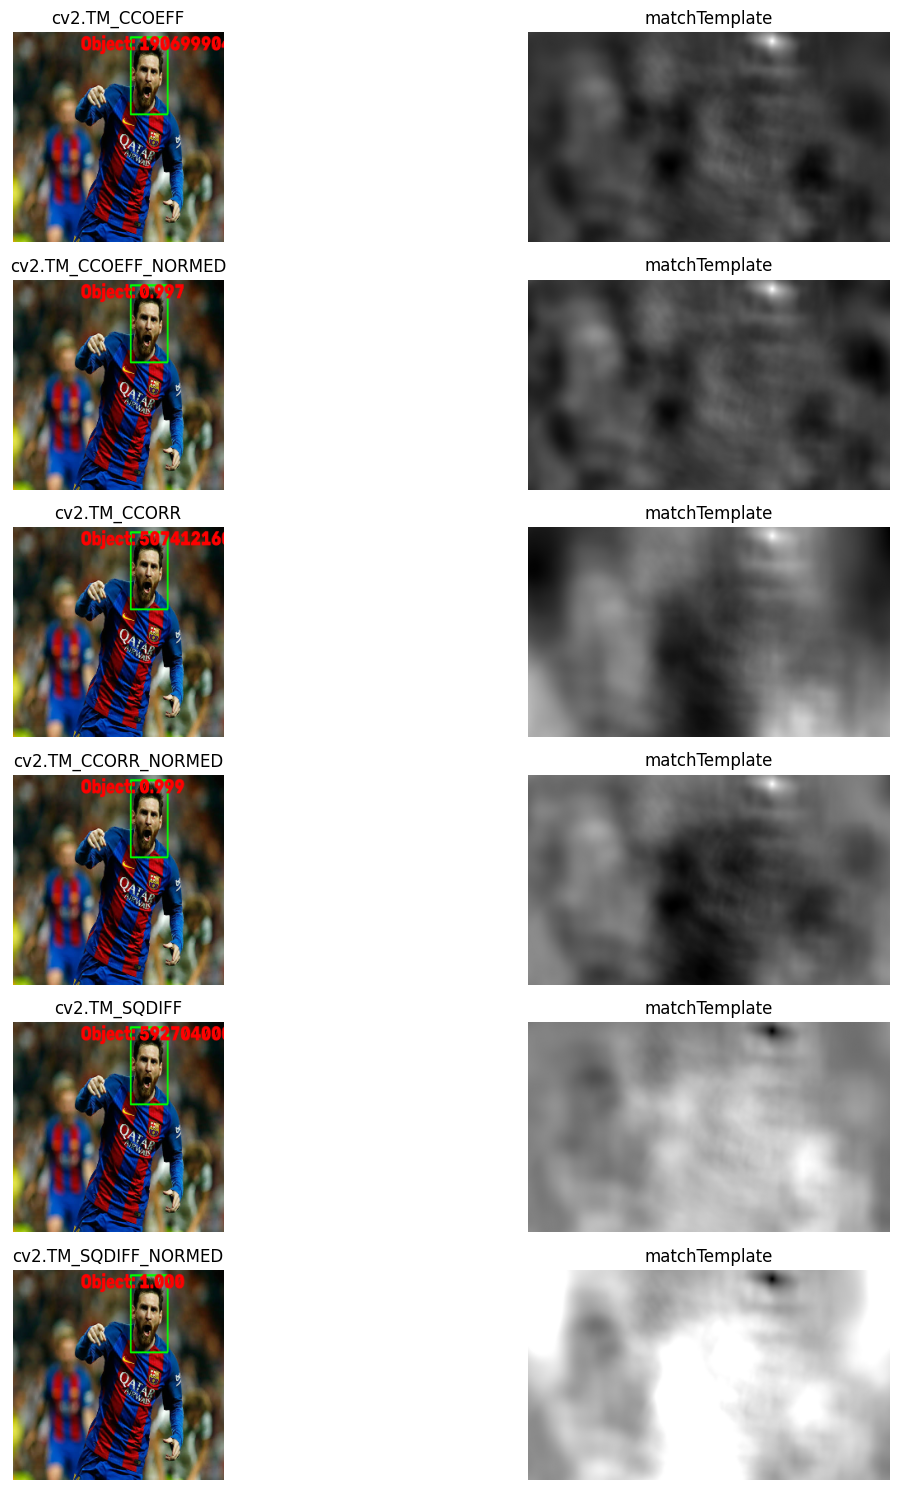

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread("messi.jpg")
template=cv2.imread("face_messi.jpg")
h,w=template.shape[:2]
methods=["cv2.TM_CCOEFF", "cv2.TM_CCOEFF_NORMED", "cv2.TM_CCORR",
         "cv2.TM_CCORR_NORMED", "cv2.TM_SQDIFF", "cv2.TM_SQDIFF_NORMED"]
plt.figure(figsize=(15,15))
for idx,method in enumerate(methods):
    img_cop=img.copy()
    plt.subplot(6,2,idx*2+1)

    result=cv2.matchTemplate(img,template,eval(method))
    min_val,max_val,min_loc,max_loc=cv2.minMaxLoc(result)
    print("max_val",max_val)
    bottom_right=(top_left[0]+w,top_left[1]+h)

    if method in["cv2.TM_SQDIFF","cv2.TM_SQDIFF_NORMED"]:
        top_left=min_loc
    else:
        top_left=max_loc
   
    cv2.rectangle(img_cop,top_left,bottom_right,(0,255,0),3)
    cv2.putText(img_cop,f"Object: {max_val:.3f}",(top_left[0]-150,top_left[1]+30),cv2.FONT_HERSHEY_COMPLEX_SMALL,2,(0,0,255),5)
    img_cop=cv2.resize(img_cop,(256,256))
    plt.imshow(cv2.cvtColor(img_cop, cv2.COLOR_BGR2RGB))
    plt.title(method)
    plt.axis('off')
    plt.subplot(6,2,idx*2+2)
    plt.imshow(result,cmap='gray')
    plt.title("matchTemplate")
    plt.axis('off')
    
plt.tight_layout()
plt.show()
     